<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/10_bar_sizeV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
!pip install astropy
!pip install astrodendro
!pip install sep
!pip install photutils


In [136]:
import numpy as np
from astropy.io import fits
import sep
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.isophote import EllipseGeometry, Ellipse
from matplotlib.patches import Ellipse as MplEllipse
from matplotlib.colors import LogNorm
from astropy.stats import mad_std

In [143]:

def display_image(fileImage):
  hdul = fits.open(fileImage)

  header = hdul[0].header
  data = hdul[0].data

  collapsedCube = np.sum(data, axis=0)

  image_data = collapsedCube.astype(float)

  print(f"Data Shape: {data.shape}")

  good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)
  norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=98.5)

  fig, axes = plt.subplots(figsize=(10, 10))
  im = axes.imshow(image_data, cmap='gray_r', origin='lower', norm=norm, interpolation='nearest')
  fig.colorbar(im, label="Pixel Brightness (Log Scale)", shrink=0.78, aspect=10)

  plt.show()

Data Shape: (11, 126, 121)


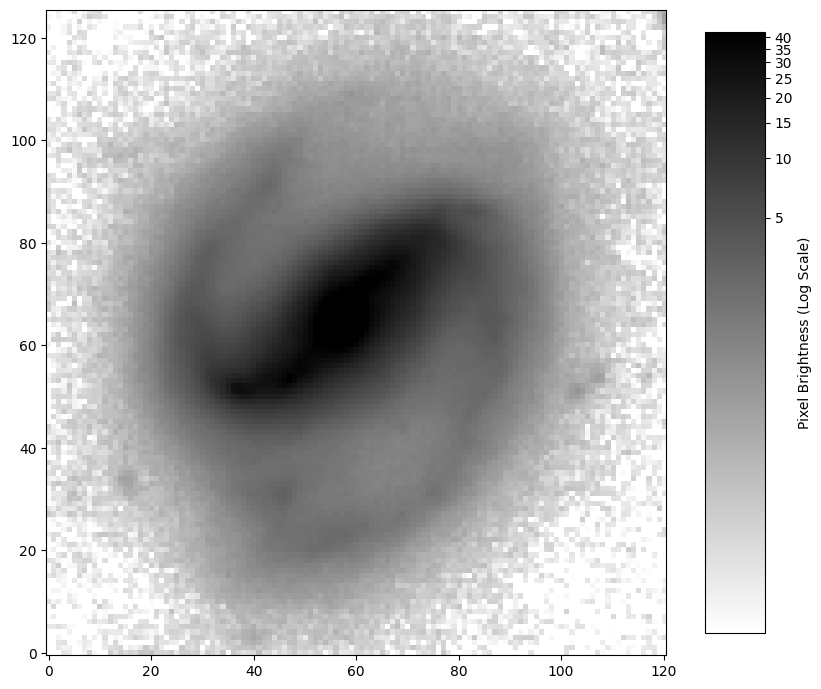

In [145]:
originalImage = "barred1.fits"

display_image(originalImage)

Centering on brightest pixel: (57, 65)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Successfully fit 73 isophotes.
Bar found! Peak ellipticity is at radius = 25.27 pixels
Estimated Bar Length: 50.54 pixels


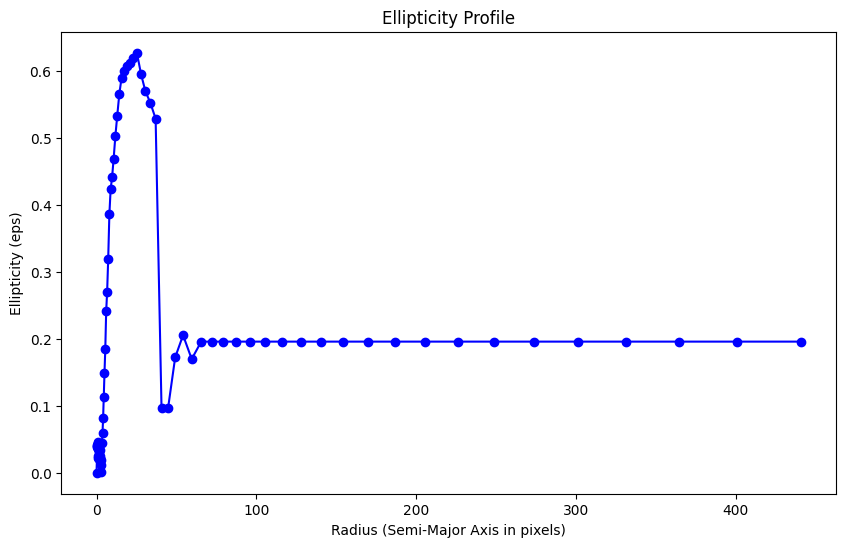

In [146]:

filename = originalImage
hdul = fits.open(filename)

header = hdul[0].header
data = hdul[0].data

collapsedCube = np.sum(data, axis=0)

y_center, x_center = np.unravel_index(np.argmax(collapsedCube), collapsedCube.shape)
print(f"Centering on brightest pixel: ({x_center}, {y_center})")


g = EllipseGeometry(x0=x_center, y0=y_center, sma=5.0, eps=0.2, pa=0.0)

ellipse = Ellipse(collapsedCube, geometry=g)

try:
    isolist = ellipse.fit_image(maxsma=450, fix_center=True)
    print(f"Successfully fit {len(isolist)} isophotes.")
except Exception as e:
    print(f"Error: Isophote fit failed. {e}")

if 'isolist' in locals() and len(isolist) > 1:
    plt.figure(figsize=(10, 6))

    # x is the size of each ellipse
    #y is the ovalness of each ellipse
    plt.plot(isolist.sma, isolist.eps, 'bo-')


    plt.xlabel('Radius (Semi-Major Axis in pixels)')
    plt.ylabel('Ellipticity (eps)')
    plt.title('Ellipticity Profile')

    # ignore all the measurements smaller than 10 pixels
    valid_fits = isolist.sma > 3

    # out of the valid ellipses, we take only the biggest one. that'll be the radius
    # the major axis
    bar_radius_pixels = isolist.sma[valid_fits][np.argmax(isolist.eps[valid_fits])]
    print(f"Bar found! Peak ellipticity is at radius = {bar_radius_pixels:.2f} pixels")

    # The bar's length is 2 * its radius
    bar_length_pixels = 2 * bar_radius_pixels
    print(f"Estimated Bar Length: {bar_length_pixels:.2f} pixels")

    plt.show()

else:
    print("Fit failed, no plot to show.")

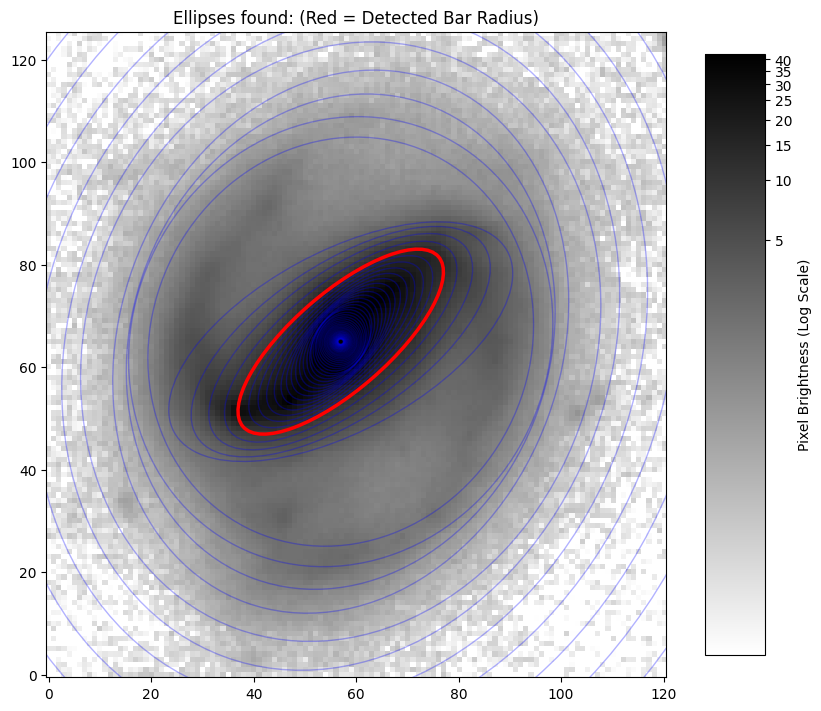

In [147]:

image_data = collapsedCube.astype(float)

good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)
norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=98.5)

fig, axes = plt.subplots(figsize=(10, 10))
im = axes.imshow(image_data, cmap='gray_r', origin='lower', norm=norm)
fig.colorbar(im, label="Pixel Brightness (Log Scale)", shrink=0.78, aspect=10)

# Looping through the isophotes and draw them
for iso in isolist:

    angle_deg = np.degrees(iso.pa)

    smi = iso.sma * (1 - iso.eps)

    # Check if this is the one found previously.
    is_bar = np.isclose(iso.sma, bar_radius_pixels)

    #Red for the bar, blue for others
    color = 'red' if is_bar else 'blue'
    alpha = 1.0 if is_bar else 0.3
    linewidth = 2.5 if is_bar else 1.0

    e = MplEllipse(xy=(iso.x0, iso.y0),
                   width=2*iso.sma,
                   height=2*smi,
                   angle=angle_deg,
                   edgecolor=color,
                   facecolor='none',
                   linewidth=linewidth,
                   alpha=alpha)

    plt.gca().add_patch(e)

plt.title(f"Ellipses found: (Red = Detected Bar Radius)")
plt.show()